# Deliverable 2 – Building an initial neural network

In [ ]:
# Sprint 2 – Simple model and initial evaluation
# 1. Choice of network architecture
# ● Objective: Identify the deep learning architecture best suited to the nature of the data and the prediction task.
# ● Architectures considered:
# MLP: for tabular data without sequential or spatial dependencies.
# CNN / ResNet / DenseNet: for spatially structured data (images, signals).
# RNN / LSTM / GRU: if the data has temporal dependencies.
# Transformers: for long sequences or complex data (text, time series).
# GNN: for relational data (graphs).
# ● Final decision:
# Initial implementation with an MLP (Multi-Layer Perceptron), adapted to tabular data.
# ● Justification:
# Simple architecture to establish a robust baseline.
# Ease of interpretation of layers.
# 2. Construction of the neural network (MLP)
# ● Implemented structure:
# Input: input_shape = 10 (10 explanatory variables)
# Hidden layer 1: 8 neurons – ReLU activation
# Hidden layer 2: 4 neurons – ReLU activation
# Output layer: 1 neuron – tanh activation (for binary or centered continuous prediction)
# ● Technical choices:
# Loss function: binary_crossentropy or MSE depending on the nature of the target
# Optimizer: Adam
# Weight initialization: He normal
# ● Justification:
# ReLU activation promotes non-linearity and limits gradient issues.
# Architecture is sufficiently lightweight to avoid initial overfitting.
 
# 3. Training and evaluation
# ● Training phase:
# Epochs = 50, batch_size = 32 (as an example)
# Early stopping on validation loss
# ● Performance evaluation:
# AUC-ROC: for the model's ability to distinguish between classes
# Confusion matrix: to assess accuracy, recall, and specificity
# ● Justification:
# AUC is more robust in the context of unbalanced classes
# 4. Analysis of the decision threshold
# ● Objective: Optimize the classification threshold in relation to a business objective (precision, F1, recall, etc.)
# ● Method:
# Generation of the F1 curve based on the decision threshold
# Choice of optimal threshold = maximum F1 or according to business constraints (min FP, max recall, etc.)
# ● Justification:
# Promotes a compromise tailored to the criticality of false positives/negatives.
# 5. Monitoring of experiments
# ● Implementation of minimum traceability of experiments
# Automatic logs (via TensorBoard, MLFlow, or simple CSV/logs)
# Model versioning: backup in .h5 or .pt format with timestamp
# Backup of training parameters (architecture, seed, hyperparams)
# ● Comparative experiments (at least 3 architectures):
# MLP baseline (simple, shallow)
# Extended MLP (deeper layers or dropout)
# ResNet-like Dense MLP (with skip connections on dense layers)

# ● Justification:
# Assess robustness, generalizability, and computational costs
# 6. Interim report
# ● Contents:
# Presentation of performance metrics (AUC, F1, precision, recall, etc.)
# Justified technical choices for each version
# Comparative analysis of results
# Proposed areas for improvement:
# ■   	Hyperparameter optimization (GridSearch, Optuna, etc.)
# ■   	Testing advanced architectures (Transformers, TabNet, etc.)
# ■   	Feature engineering or enhanced encoding

## Importing Necessary Packages

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split 
from sklearn.metrics import confusion_matrix, classification_report, f1_score, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense 
from tensorflow.keras.callbacks import EarlyStopping
import keras
import matplotlib.pyplot as plt

## Load The Processed Data From The First Deliverable

In [4]:
# Load the data from processed_X.csv and processed_y.csv
X = pd.read_csv('..\\datasets\\processed_X.csv')
y = pd.read_csv('..\\datasets\\processed_y.csv')

In [5]:
# print the shapes of the data
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (236182, 21)
Shape of y: (236182, 1)


## Train Test Split

In [6]:
# split the data into training and testing sets
X_temp, X_val, y_temp, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

## MLP BaseLine

### Building the Model

In [7]:
# Building the MLP model
model = Sequential(
    [
        Dense(8, activation="relu", input_shape=(X_train.shape[1],)),
        Dense(4, activation="relu"),
        Dense(1, activation="tanh"),
    ]
)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["AUC"],
)
model.summary()

c:\Users\ethan\OneDrive\Documents\Strathmore\CESI\deep_learning\Group_work\deep-learning-diabete-prediction\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 217 (868.00 B)

 Trainable params: 217 (868.00 B)

 Non-trainable params: 0 (0.00 B)

### Training the Model

In [8]:
early_stopping = EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True, verbose=1)

In [9]:
# Train the model
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=0,
)

Epoch 29: early stopping
Restoring model weights from the end of the best epoch: 14.


### Evaluate the Model

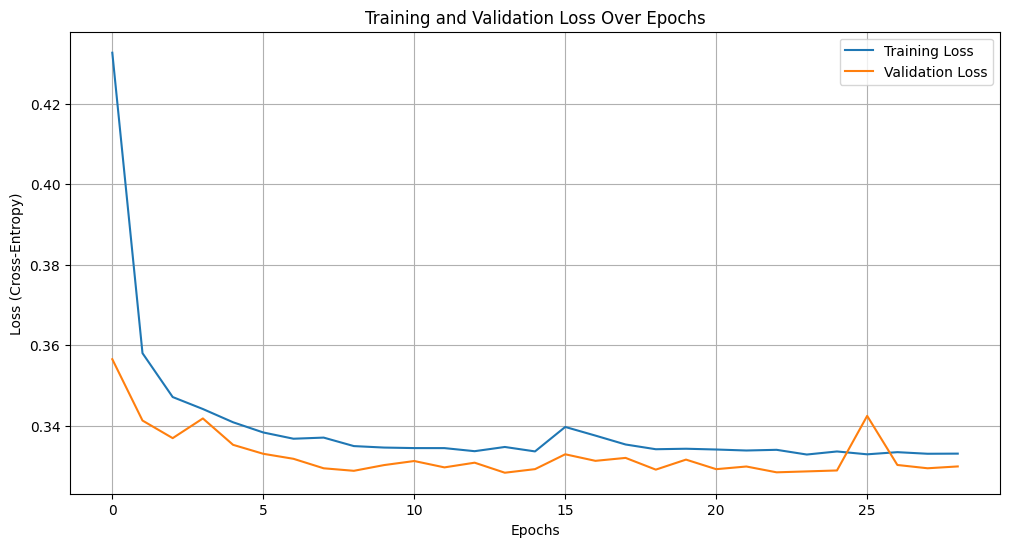

In [10]:
# Plot training and validation loss over epochs on the same graph
plt.figure(figsize=(12, 6))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss (Cross-Entropy)")
plt.legend()
plt.grid()

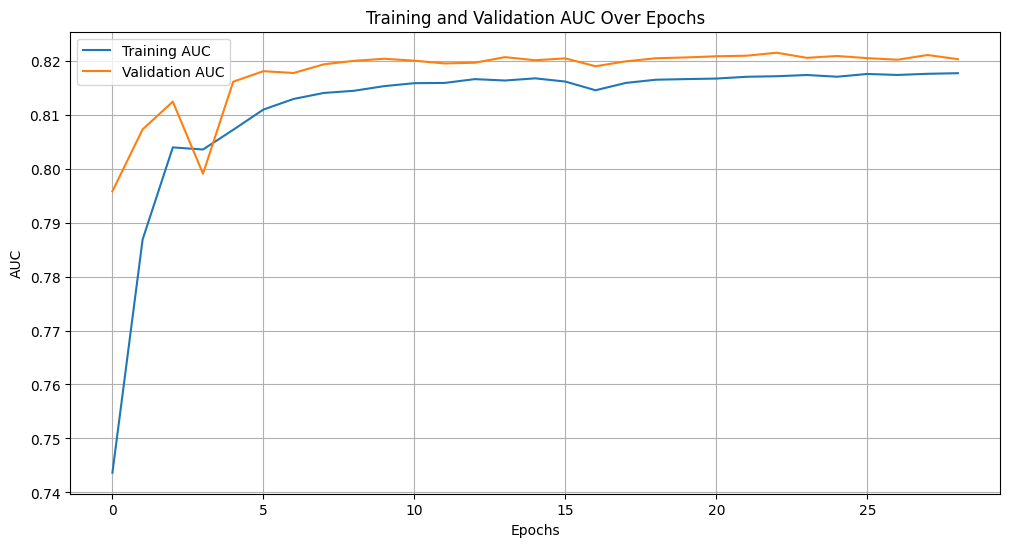

In [11]:
# Plot training and validation AUC over epochs on the same graph
plt.figure(figsize=(12, 6))
plt.plot(history.history["AUC"], label="Training AUC")
plt.plot(history.history["val_AUC"], label="Validation AUC")
plt.title("Training and Validation AUC Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("AUC")
plt.legend()
plt.grid()

In [12]:
# Evaluate the model on the test set using AUC-ROC 
test_loss, test_auc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test AUC: {test_auc:.4f}')

Test AUC: 0.8155


In [13]:
# Confusion matrix and classification report
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

1477/1477 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.99      0.92     40125
           1       0.60      0.12      0.20      7112

    accuracy                           0.86     47237
   macro avg       0.73      0.55      0.56     47237
weighted avg       0.82      0.86      0.81     47237



Confusion Matrix:


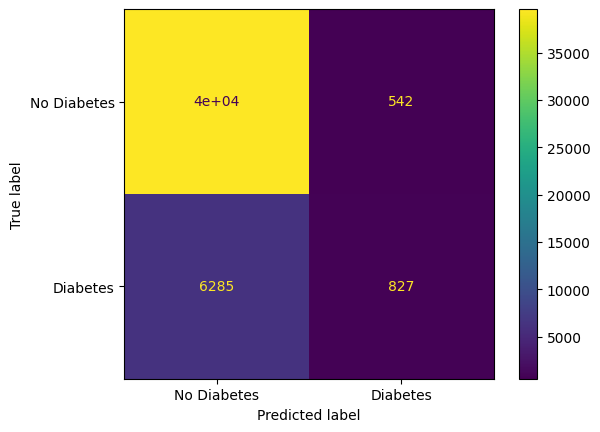

In [14]:
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["No Diabetes", "Diabetes"]) 
cm_display.plot()
plt.show() 

### Analysis of the decision threshold

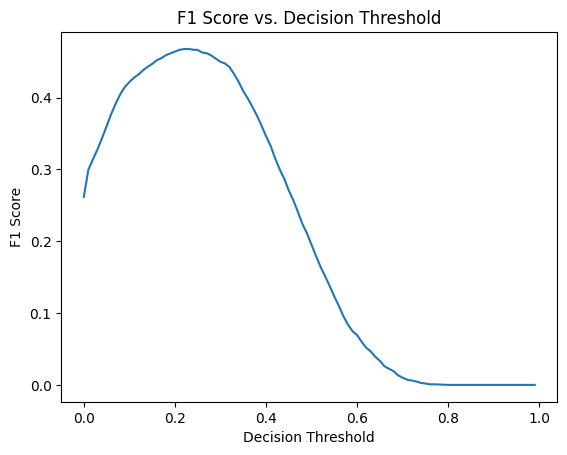

In [15]:
# Generation of the F1 curve based on the decision threshold
thresholds = np.arange(0.0, 1.0, 0.01)
f1_scores = [f1_score(y_test, (y_pred_prob > t).astype(int)) for t in thresholds]

plt.plot(thresholds, f1_scores)
plt.xlabel("Decision Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs. Decision Threshold")
plt.show()

In [16]:
max_f1_index = np.argmax(f1_scores)
optimal_threshold = thresholds[max_f1_index]
print(f"Optimal Threshold: {optimal_threshold:.2f} with F1 Score: {f1_scores[max_f1_index]:.4f}")

Optimal Threshold: 0.23 with F1 Score: 0.4678


In [17]:
# Confusion matrix and classification report
y_pred_prob_val = model.predict(X_val)
y_pred_val = (y_pred_prob_val > optimal_threshold).astype(int)
print("\nClassification Report:")
print(classification_report(y_val, y_pred_val))

1477/1477 ━━━━━━━━━━━━━━━━━━━━ 1s 930us/step

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87     40294
           1       0.38      0.64      0.48      6943

    accuracy                           0.79     47237
   macro avg       0.65      0.73      0.67     47237
weighted avg       0.85      0.79      0.81     47237



Confusion Matrix:


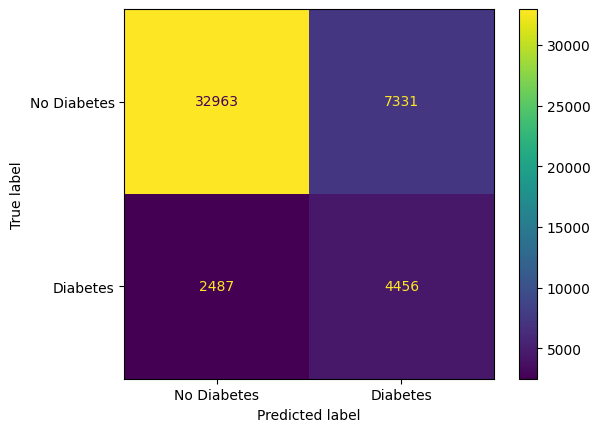

In [18]:
print("Confusion Matrix:")
cm_val = confusion_matrix(y_val, y_pred_val)
cm_display_val = ConfusionMatrixDisplay(confusion_matrix = cm_val, display_labels = ["No Diabetes", "Diabetes"]) 
cm_display_val.plot()
plt.show() 

### Save Model

## Extended MLP (deeper layers or dropout)

## ResNet-like Dense MLP (with skip connections on dense layers)

## Comparative Analysis of Models